In [1]:
from sbi_particle_physics.managers.plotter import Plotter
from sbi_particle_physics.managers.backup import Backup
from sbi_particle_physics.config import DATA_DIR, PLOT_COLORS, MODELS_DIR, DEFAULT_STRIDE, DEFAULT_PRE_N, DEFAULT_PRERUNS, ACCEPTANCE_COEFFS_PATH, C9
import matplotlib as plt
from sbi_particle_physics.managers.improvements import Improvements
import numpy as np
from sbi_particle_physics.managers.imperfections_diagnostics import ImperfectionsDiagnostics
from sbi_particle_physics.objects.model import Model
from sbi_particle_physics.managers.model_diagnostics import ModelDiagnostics

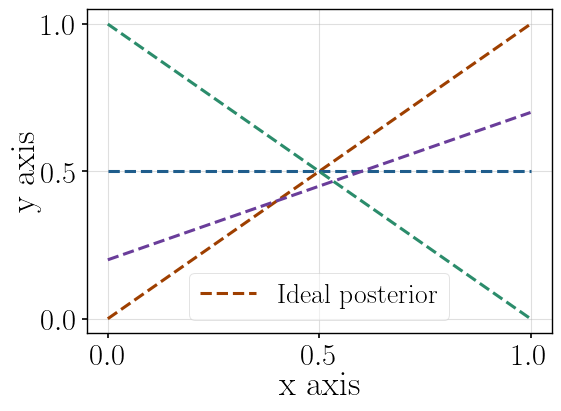

In [2]:
Plotter.poster_plot()

Loading files:   0%|          | 0/1 [00:00<?, ?it/s]

Loading a file
torch.Size([50, 10000, 4])


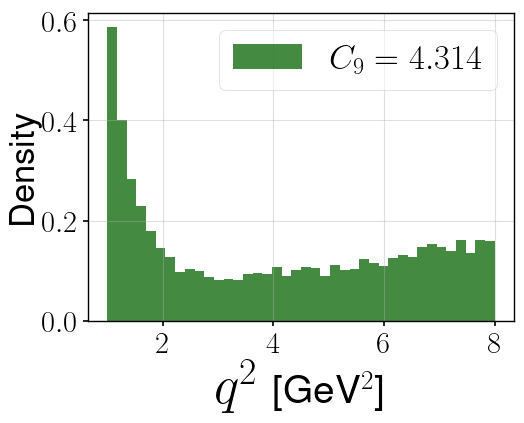

In [3]:
plt.rcParams['font.family'] = 'Helvetica' #Helvetica'#'DejaVu Sans'
#plt.rcParams['font.weight'] = 'medium'
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=PLOT_COLORS)
device = "cpu"
paths = Backup.detect_files(DATA_DIR / "data_3")
raw_data, raw_parameters, metadata = Backup.load_data(paths[0:1], device=device)
print(raw_data.shape)
Plotter.plot_a_sample_1D(raw_data[0,:,0], raw_parameters[0], r"$\boldmath{q^2}$ \fontsize{28}{12}\selectfont [GeV$^2$]")

In [4]:
model = Backup.load_model_for_inference_basic(MODELS_DIR / "training_13", device)


Model loaded from /home/hep/nrc25/sbi-particle-physics/models/training_13/epoch_2000.pt


In [5]:
files = Backup.detect_files(DATA_DIR / "data_3")[-5:] # 5 last files
raw_data, raw_parameters, _ = Backup.load_data(files, model.device)
raw_data = raw_data[:,:model.n_points]
raw_parameters = raw_parameters[:,:model.n_points]
data = model.normalizer.normalize_data(raw_data)
parameters = model.normalizer.normalize_parameters(raw_parameters)

Loading files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading a file
Loading a file
Loading a file
Loading a file
Loading a file


  0%|          | 0/100000 [00:00<?, ?it/s]

torch.Size([100000, 1])
tensor([[4.0193],
        [4.0243],
        [4.0258],
        [4.0546],
        [4.0730]])


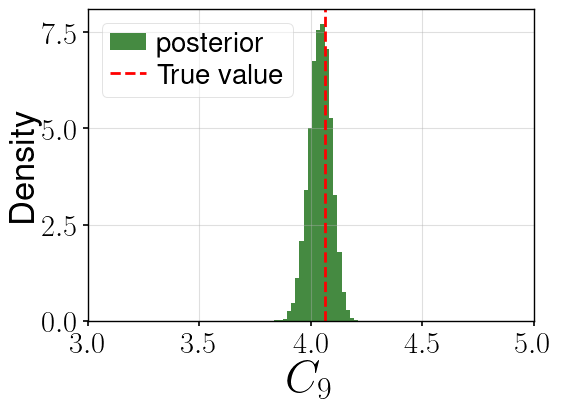

In [6]:
true_parameter = parameters[0]
observed_sample = data[0]
sampled_parameters = model.draw_parameters_from_predicted_posterior(observed_sample, n_parameters=100000)
sampled_parameters = sampled_parameters.squeeze(0)
print(sampled_parameters.shape)
print(sampled_parameters[:5])
Plotter.plot_a_posterior_parameter(sampled_parameters[:,0], "$C_9$", true_parameter[0].item(), range=(3,5))

Loading files:   0%|          | 0/1 [00:00<?, ?it/s]

Loading a file
Model loaded from /home/hep/nrc25/sbi-particle-physics/models/training_12/epoch_2000.pt


/home/hep/nrc25/sbi-particle-physics/src/sbi_particle_physics/objects/model.py:222: UserWarning: Capping max_sampling_batch_size from 10000 to 2000 to avoid excessive memory usage.
  return self.posterior.sample_batched((n_parameters,), x=observed_samples).transpose(0,1) # sbi gives it in a weird order


Drawing 100 samples for 50 observations:   0%|          | 0/100 [00:00<?, ?it/s]

Model loaded from /home/hep/nrc25/sbi-particle-physics/models/training_13/epoch_2000.pt


...

Model loaded from /home/hep/nrc25/sbi-particle-physics/models/training_20/epoch_385.pt


Drawing 100 samples for 50 observations:   0%|          | 0/100 [00:00<?, ?it/s]

Model loaded from /home/hep/nrc25/sbi-particle-physics/models/training_21/epoch_255.pt


Drawing 100 samples for 50 observations:   0%|          | 0/100 [00:00<?, ?it/s]

a = 1.1577e+01
b = 2.6030e-03
N* = a/b = 4447.6


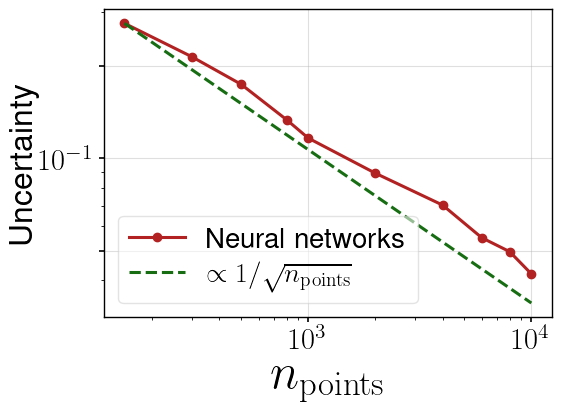

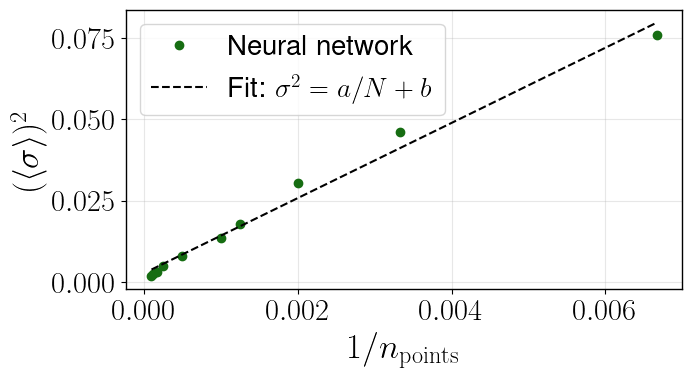

In [7]:
directories_n_points = [MODELS_DIR / f"training_{x}" for x in range(12,22)]
n_posterior_samples = 100
files = Backup.detect_files(DATA_DIR / "data_3")[-1:] # 1 last files
raw_data, raw_parameters, _ = Backup.load_data(files, device)
Improvements.plot_width_by_npoints(directories_n_points, device, raw_data, n_posterior_samples=n_posterior_samples)

Model loaded from /home/hep/nrc25/sbi-particle-physics/models/training_12/epoch_2000.pt


Drawing 100 samples for 50 observations:   0%|          | 0/100 [00:00<?, ?it/s]

Drawing 100 samples for 50 observations:   0%|          | 0/100 [00:00<?, ?it/s]

Drawing 100 samples for 50 observations:   0%|          | 0/100 [00:00<?, ?it/s]

Drawing 100 samples for 50 observations:   0%|          | 0/100 [00:00<?, ?it/s]

...

Drawing 100 samples for 50 observations:   0%|          | 0/100 [00:00<?, ?it/s]

Drawing 100 samples for 50 observations:   0%|          | 0/100 [00:00<?, ?it/s]

Drawing 100 samples for 50 observations:   0%|          | 0/100 [00:00<?, ?it/s]

Drawing 100 samples for 50 observations:   0%|          | 0/100 [00:00<?, ?it/s]

Drawing 100 samples for 50 observations:   0%|          | 0/100 [00:00<?, ?it/s]

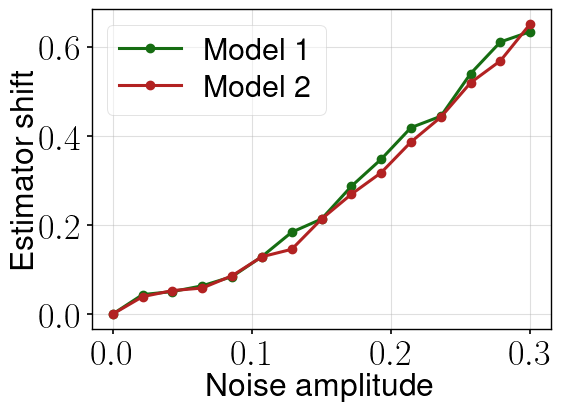

In [8]:
directories_noise = [MODELS_DIR / f"training_12", MODELS_DIR / f"training_28"]
noise_levels = np.linspace(0.0, 0.3, 15).tolist()
Improvements.plot_drift_by_noise_poster(directories_noise, device, raw_data, noise_levels=noise_levels, n_posterior_samples=n_posterior_samples, labels=["Model 1", "Model 2"])

In [9]:
n_points = 5000
model = Model(device, n_points=n_points)

model.set_prior_basic([3], [5])
model.set_simulator(stride=DEFAULT_STRIDE, pre_N=DEFAULT_PRE_N, preruns=DEFAULT_PRERUNS, use_imperfections=True, acceptance_coeffs_path=ACCEPTANCE_COEFFS_PATH)
model.set_normalizer(model.to_tensor([0,0,0,0,0]), model.to_tensor([1,1,1,1,1]))
model.simulator.imperfections.use_acceptance = False
x_sim_norm = model.simulate_data_with_parameters(model.to_tensor([[C9]]), n_points=n_points).squeeze(0)
model.simulator.imperfections.use_acceptance = True
x_sim = model.normalizer.denormalize_data(x_sim_norm)
x_accnorm = model.simulate_data_with_parameters(model.to_tensor([[C9]]), n_points=n_points).squeeze(0)
x_acc = model.normalizer.denormalize_data(x_accnorm)

Simulating samples:   0%|          | 0/1 [00:00<?, ?it/s]

/home/hep/nrc25/miniconda3/envs/mlhep/lib/python3.12/site-packages/eos/signal_pdf.py:71: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  log_proposal = pypmc.density.gauss.LocalGauss(sigma)


Pre-runs:   0%|          | 0/10 [00:00<?, ?it/s]

Main run:   0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
ImperfectionsDiagnostics.compare_simulated_vs_accepted_poster(x_sim=x_sim, x_acc=x_acc, q2_bin=(1.1,6), bins=40)

In [ ]:
model = Backup.load_model_for_inference_basic(directory=MODELS_DIR / "training_12", device=device)
data = model.normalizer.normalize_data(raw_data)
parameters = model.normalizer.normalize_parameters(raw_parameters)
ModelDiagnostics.expected_coverage_test(model, data[:400], parameters[:400], num_posterior_samples=1000)